# 3. Evaluating models' performance

## Somermeyer datasets

In [5]:
from src.analysis import compute_result_table
from src.paths import data_dir, interm_tables_dir

results = compute_result_table(data_dir, interm_tables_dir, "somermeyer")

ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [ ]:
from src.models.linear_regression import linear_regression

results = linear_regression(results, data_dir, interm_tables_dir, "somermeyer")

In [ ]:
from src.models.mlp import mlp

final_results = mlp(results, data_dir, interm_tables_dir, "somermeyer")
output_dir = interm_tables_dir / "models_evaluation" 
output_dir.mkdir(parents=True, exist_ok=True)
final_results.to_csv(output_dir / "somermeyer_all_models.csv", index=True)

In [ ]:
from src.analysis import select_best_models

select_best_models(interm_tables_dir / "models_evaluation", "somermeyer")

In [ ]:
from src.plotting import combined_plot_somermeyer
from src.paths import interm_tables_dir, main_figures_dir

combined_plot_somermeyer(interm_tables_dir / "models_evaluation", main_figures_dir)

In [ ]:
from src.paths import data_dir, interm_tables_dir, main_figures_dir
from src.analysis import combined_plot_somermeyer_with_whiskers

combined_plot_somermeyer_with_whiskers(
    models_eval_dir = interm_tables_dir / "models_evaluation",  # has somermeyer_best_models.csv
    output_dir      = main_figures_dir,                         # where figures go
    model_dir       = data_dir,                                 # raw model predictions in data_dir/somermeyer
    epi_dir         = interm_tables_dir,                        # epistasis CSVs for somermeyer
    seeds           = (0,1,2,3,4),                              # change as you like
)

In [ ]:
from src.analysis import somermeyer_top_models
from src.paths import interm_tables_dir, main_tables_dir

somermeyer_top_models(interm_tables_dir / "models_evaluation", main_tables_dir)

## Tsuboyama datasets

In [ ]:
from src.analysis import compute_result_table
from src.paths import data_dir, interm_tables_dir

results, counts = compute_result_table(data_dir, interm_tables_dir / "tsuboyama_epistatic", "tsuboyama")
counts.to_csv(interm_tables_dir / "counts.csv", index=True)

In [ ]:
from src.models.linear_regression import linear_regression

results = linear_regression(results, data_dir, interm_tables_dir / "tsuboyama_epistatic", "tsuboyama")

In [ ]:
from src.models.mlp import mlp

final_results = mlp(results, data_dir, interm_tables_dir / "tsuboyama_epistatic", "tsuboyama")
final_results.dropna(axis=1, how="all", inplace=True)
output_dir = interm_tables_dir / "models_evaluation" 
final_results.to_csv(output_dir / "tsuboyama_all_models.csv", index=True)

In [ ]:
from src.analysis import select_best_models

select_best_models(interm_tables_dir / "models_evaluation", "tsuboyama")

In [ ]:
from src.plotting import combined_plot_tsuboyama
from src.paths import main_figures_dir, interm_tables_dir

combined_plot_tsuboyama(interm_tables_dir, main_figures_dir)

In [ ]:
from src.paths import data_dir, interm_tables_dir, supp_figures_dir
from src.analysis import build_tsuboyama_N_series

build_tsuboyama_N_series(
    raw_tsuboyama_dir = interm_tables_dir / "tsuboyama_epistatic",
    model_root_dir    = data_dir,
    work_root_dir     = interm_tables_dir,
    figures_dir       = supp_figures_dir,
)


In [ ]:
from src.paths import interm_tables_dir, supp_tables_dir
from src.analysis import tsuboyama_top_models

tsuboyama_top_models(interm_tables_dir, supp_tables_dir)

In [ ]:
from src.plotting import individual_combined_plot_tsuboyama
from src.paths import interm_tables_dir, main_figures_dir

individual_combined_plot_tsuboyama(interm_tables_dir, main_figures_dir)

In [ ]:
from src.analysis import combined_plot_tsuboyama_with_whiskers
from src.paths import interm_tables_dir, main_figures_dir, data_dir

combined_plot_tsuboyama_with_whiskers(interm_tables_dir,
                                      main_figures_dir,
                                      data_dir,
                                      interm_tables_dir / "tsuboyama_epistatic")

In [ ]:
from src.paths import interm_tables_dir, main_tables_dir
from src.analysis import tsuboyama_top_models_by_seq

tsuboyama_top_models_by_seq(interm_tables_dir, main_tables_dir)

In [ ]:
from src.plotting import tsuboyama_epi_distribution_plots
from src.paths import interm_tables_dir, supp_figures_dir

tsuboyama_epi_distribution_plots(interm_tables_dir / "tsuboyama_epistatic", supp_figures_dir / "5_tsuboyama_epi_distribution", fit="kde")

In [ ]:
from src.plotting import plot_epi_hist_gt400_onepage, plot_epi_hist_200to400_onepage, plot_epi_hist_100to200_onepage
from src.paths import interm_tables_dir, supp_figures_dir

plot_epi_hist_gt400_onepage(
    input_dir=interm_tables_dir / "tsuboyama_epistatic",
    out_png=supp_figures_dir / "epi_400_kde.png",
    fit="kde",    # или "gaussian", или None
    hist=True,
    bins=70
)

plot_epi_hist_200to400_onepage(
    input_dir=interm_tables_dir / "tsuboyama_epistatic",
    out_png=supp_figures_dir / "epi_200_400_kde.png",
    fit="kde",
    hist=True,
    bins=70
)

Saved: /wibicomfs/STBS/anastasia/epi_clean/results/figures/supplementary/epi_400_kde.png (6 panels)
Saved: /wibicomfs/STBS/anastasia/epi_clean/results/figures/supplementary/epi_200_400_kde.png (5 panels)


In [ ]:
from src.plotting import plot_epi_hist_gt400_onepage, plot_epi_hist_200to400_onepage, plot_epi_hist_100to200_onepage
from src.paths import interm_tables_dir, supp_figures_dir

plot_epi_hist_gt400_onepage(
    input_dir=interm_tables_dir / "tsuboyama_epistatic",
    out_png=supp_figures_dir / "epi_400_counts.png",
    hist=True,
    density=False,
    bins=70
)

plot_epi_hist_200to400_onepage(
    input_dir=interm_tables_dir / "tsuboyama_epistatic",
    out_png=supp_figures_dir / "epi_200_400_counts.png",
    hist=True,
    density=False,
    bins=70
)

Saved: /wibicomfs/STBS/anastasia/epi_clean/results/figures/supplementary/epi_400_counts.png (6 panels)
Saved: /wibicomfs/STBS/anastasia/epi_clean/results/figures/supplementary/epi_200_400_counts.png (5 panels)


In [ ]:
from src.paths import data_dir, supp_figures_dir, interm_tables_dir
from src.analysis import combined_plot_tsuboyama_top50


combined_plot_tsuboyama_top50(
    model_root_dir=data_dir,
    epi_dir=interm_tables_dir / "tsuboyama_epistatic",
    dataset_name="MYO3_YEAST_Tsuboyama_2023_2BTT",
    models_eval_dir=interm_tables_dir / "models_evaluation",
    output_dir=supp_figures_dir
)

[OK] saved /wibicomfs/STBS/anastasia/epi_clean/results/figures/supplementary/6_combined_plot_MYO3_YEAST_2BTT_top50_whiskers.png


In [ ]:
from src.paths import data_dir, supp_figures_dir, interm_tables_dir
from src.analysis import combined_plot_tsuboyama_top50


combined_plot_tsuboyama_top50(
    model_root_dir=data_dir,
    epi_dir=interm_tables_dir / "tsuboyama_epistatic",
    dataset_name="POLG_PESV_Tsuboyama_2023_2MXD",
    models_eval_dir=interm_tables_dir / "models_evaluation",
    output_dir=supp_figures_dir
)

[OK] saved /wibicomfs/STBS/anastasia/epi_clean/results/figures/supplementary/6_combined_plot_POLG_PESV_2MXD_top50_whiskers.png


# Tsuboyama heatmaps

In [ ]:
from pathlib import Path
from typing import Union, Tuple
import numpy as np
import pandas as pd
from scipy.stats import friedmanchisquare, wilcoxon

def _wilcoxon_pmat_adj_one_sided(models_eval_dir: Union[str, Path],
                                 alpha: float = 0.05,
                                 move_baselines_last: bool = True
                                 ) -> Tuple[pd.DataFrame, float, list]:
    """
    Compute asymmetric Holm-adjusted p-value matrix for one-sided Wilcoxon:
    cell (i,j) tests H1: model_i > model_j on epistatic-only Spearman.

    Returns:
      pmat_adj     : DataFrame (models × models) of Holm-adjusted p-values
      p_friedman   : Friedman omnibus p-value (info only)
      ordered      : list of model names in the applied order
    """
    models_eval_dir = Path(models_eval_dir)

    # Read best models, keep *_epistatic only (rows=models, cols=datasets)
    df_best = pd.read_csv(models_eval_dir / "tsuboyama_best_models.csv", index_col=0)
    epi = df_best.filter(regex=r"_epistatic$").copy()
    epi.columns = [c.replace("_epistatic", "") for c in epi.columns]
    epi = epi.apply(pd.to_numeric, errors="coerce")

    # Datasets × models; drop datasets with any NaN across selected models
    epi_T = epi.T
    epi_clean = epi_T.dropna(axis=0, how="any")
    if epi_clean.shape[0] < 2 or epi_clean.shape[1] < 2:
        raise ValueError("Not enough complete datasets or models after dropping NaNs.")

    models = epi_clean.columns.to_list()
    k = len(models)

    # Omnibus (for info)
    stat, p_friedman = friedmanchisquare(*[epi_clean[m].values for m in models])
    print(f"Friedman χ²={stat:.3f}, p={p_friedman:.3g}")

    # Pairwise one-sided Wilcoxon for H1: row > col
    pmat = np.full((k, k), np.nan, dtype=float)
    pairs, pvals = [], []
    for i in range(k):
        for j in range(k):
            if i == j:
                continue
            a = epi_clean[models[i]].to_numpy()
            b = epi_clean[models[j]].to_numpy()
            d = a - b
            d = d[d != 0]  # drop exact zeros
            if d.size == 0:
                p = 1.0
            else:
                p = wilcoxon(d, alternative="greater", zero_method="wilcox").pvalue
            pmat[i, j] = p
            pairs.append((i, j))
            pvals.append(p)

    pvals = np.asarray(pvals, dtype=float)

    # Holm step-down correction over all directed tests
    def _holm_step_down(p):
        m = p.size
        order = np.argsort(p)
        adj = np.empty_like(p, dtype=float)
        running_max = 0.0
        for rank, idx in enumerate(order):
            factor = m - rank
            adj_val = p[idx] * factor
            running_max = max(running_max, adj_val)
            adj[idx] = running_max
        return np.minimum(adj, 1.0)

    adj_all = _holm_step_down(pvals)

    # Back to square matrix
    pmat_adj = np.full_like(pmat, np.nan, dtype=float)
    for (i, j), p_adj in zip(pairs, adj_all):
        pmat_adj[i, j] = p_adj
    pmat_adj = pd.DataFrame(pmat_adj, index=models, columns=models)

    # Order models (optional): move baselines to the end
    if move_baselines_last:
        base = [m for m in ["Linear_regression", "MLP"] if m in pmat_adj.index]
        core = [m for m in pmat_adj.index if m not in base]
        ordered = core + base
        pmat_adj = pmat_adj.loc[ordered, ordered]
    else:
        ordered = pmat_adj.index.tolist()

    return pmat_adj, p_friedman, ordered

In [ ]:
from pathlib import Path
from typing import Optional, Union, Tuple, List

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib import colormaps as cmaps

def wilcoxon_heatmap_epistatic_best_full_gradient(
    models_eval_dir: Union[str, Path],
    title: str = "Tsuboyama — Wilcoxon (row > col), Holm-adjusted p-values",
    out_png: Optional[Union[str, Path]] = None,
    out_csv: Optional[Union[str, Path]] = None,
    figsize: Tuple[int, int] = (20, 20),
    alpha: float = 0.05,
    fontsize: int = 12,
    bin_edges: Optional[List[float]] = None,     # e.g. [0, 1e-3, 1e-2, 0.05, 0.1, 0.25, 0.5, 1.0]
    bin_colors: Optional[List[str]] = None,      # if None, build with pivot at alpha
):
    """
    Full matrix with a stepped p-value legend (discrete bins). Diagonal is white.
    Uses Holm-adjusted one-sided Wilcoxon p-values for H1: row > col.

    ORDERING: models are sorted by the **minimum adjusted p-value in the row**
              (ascending; smaller = higher). Ties -> by row median p, then alphabetically.
    """
    # 1) get adjusted p-values (asymmetric) for H1: row > col
    pmat_adj, p_friedman, _ = _wilcoxon_pmat_adj_one_sided(models_eval_dir, alpha=alpha)

    # --- Sorting by row sum (lower sum = higher/earlier) ---
    order_frame = pmat_adj.copy()
    np.fill_diagonal(order_frame.values, np.nan)              # ignore diagonal
    row_sum = order_frame.sum(axis=1, skipna=True).fillna(np.inf)

    # primary key: row_sum asc; tie-break: name alphabetical
    order = sorted(
        pmat_adj.index.tolist(),
        key=lambda m: (row_sum[m], m.lower())
    )

    # apply order to both axes
    pmat_adj = pmat_adj.loc[order, order]

    # 2) optionally save numeric matrix
    if out_csv is not None:
        Path(out_csv).parent.mkdir(parents=True, exist_ok=True)
        pmat_adj.to_csv(out_csv, index=True)

    # 3) bins & colors with pivot at alpha
    if bin_edges is None:
        bin_edges = [0.0, 1e-3, 1e-2, alpha, 0.10, 0.25, 0.50, 1.0]
    if not (abs(bin_edges[0] - 0.0) < 1e-12 and abs(bin_edges[-1] - 1.0) < 1e-12):
        raise ValueError("bin_edges must start at 0.0 and end at 1.0.")
    if sorted(bin_edges) != list(bin_edges):
        raise ValueError("bin_edges must be non-decreasing.")
    n_bins = len(bin_edges) - 1

    def _pivot_colors(edges, alpha_val, base_name="RdYlGn"):
        base = cmaps.get(base_name)
        cols = []
        for i in range(len(edges) - 1):
            c = 0.5 * (edges[i] + edges[i+1])  # bin center in [0,1]
            if c <= alpha_val:
                u = 0.0 if alpha_val == 0 else 0.5 * (c / alpha_val)      # red→yellow
            else:
                u = 0.5 + 0.5 * (c - alpha_val) / (1.0 - alpha_val)       # yellow→green
            cols.append(base(u))
        return cols

    if bin_colors is None:
        bin_colors = _pivot_colors(bin_edges, alpha_val=alpha)
    if len(bin_colors) != n_bins:
        raise ValueError("len(bin_colors) must equal len(bin_edges)-1.")

    cmap = ListedColormap(bin_colors)
    cmap.set_bad("white")  # diagonal NaN → white
    norm = BoundaryNorm(bin_edges, ncolors=cmap.N, clip=True)

    # 4) colorbar labels
    def _fmt_p(x: float) -> str:
        if x < 1e-3: return f"{x:.0e}"
        if x < 0.01: return f"{x:.3f}".rstrip("0").rstrip(".")
        if x < 0.1:  return f"{x:.2f}".rstrip("0").rstrip(".")
        return f"{x:.2f}".rstrip("0").rstrip(".")

    bin_labels = []
    for i in range(n_bins):
        L, R = bin_edges[i], bin_edges[i+1]
        if np.isclose(R, alpha):
            bin_labels.append(f"< {_fmt_p(R)}")
        elif np.isclose(L, alpha):
            bin_labels.append(f"≥ {_fmt_p(L)}")
        elif i == 0:
            bin_labels.append(f"< {_fmt_p(R)}")
        elif i == n_bins - 1:
            bin_labels.append(f"≥ {_fmt_p(L)}")
        else:
            bin_labels.append(f"{_fmt_p(L)} – {_fmt_p(R)}")

    # 5) plot
    plt.figure(figsize=figsize)
    plot_df = pmat_adj.copy()
    np.fill_diagonal(plot_df.values, np.nan)

    ax = sns.heatmap(
        plot_df,
        cmap=cmap,
        norm=norm,
        annot=False,
        cbar=True,
        cbar_kws={"shrink": 0.6, "aspect": 30},
        square=True,
        linewidths=0.5,
        linecolor="white",
    )

    cbar = ax.collections[0].colorbar
    tick_positions = [(bin_edges[i] + bin_edges[i+1]) / 2 for i in range(n_bins)]
    cbar.set_ticks(tick_positions)
    cbar.set_ticklabels(bin_labels)
    cbar.ax.tick_params(labelsize=fontsize)
    cbar.set_label("Holm-adjusted p-value (row > col)", fontsize=fontsize)

    #ax.set_title(f"{title}\nFriedman p={p_friedman:.3g}", fontsize=fontsize + 2)
    ax.set_title(title, fontsize=fontsize + 2)
    ax.tick_params(axis="x", labelrotation=90, labelsize=fontsize)
    ax.tick_params(axis="y", labelsize=fontsize)

    plt.tight_layout()
    if out_png is not None:
        Path(out_png).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(out_png, dpi=300, bbox_inches="tight")
        print(f"[OK] saved {out_png}")
    else:
        plt.show()

    return pmat_adj, p_friedman

Friedman χ²=571.463, p=3.28e-95
[OK] saved /wibicomfs/STBS/anastasia/epi_clean/results/tables/intermediate/models_evaluation/tsuboyama_wilcoxon_full_gradient.png
Saved full gradient heatmap. Friedman p = 3.2835970968909535e-95


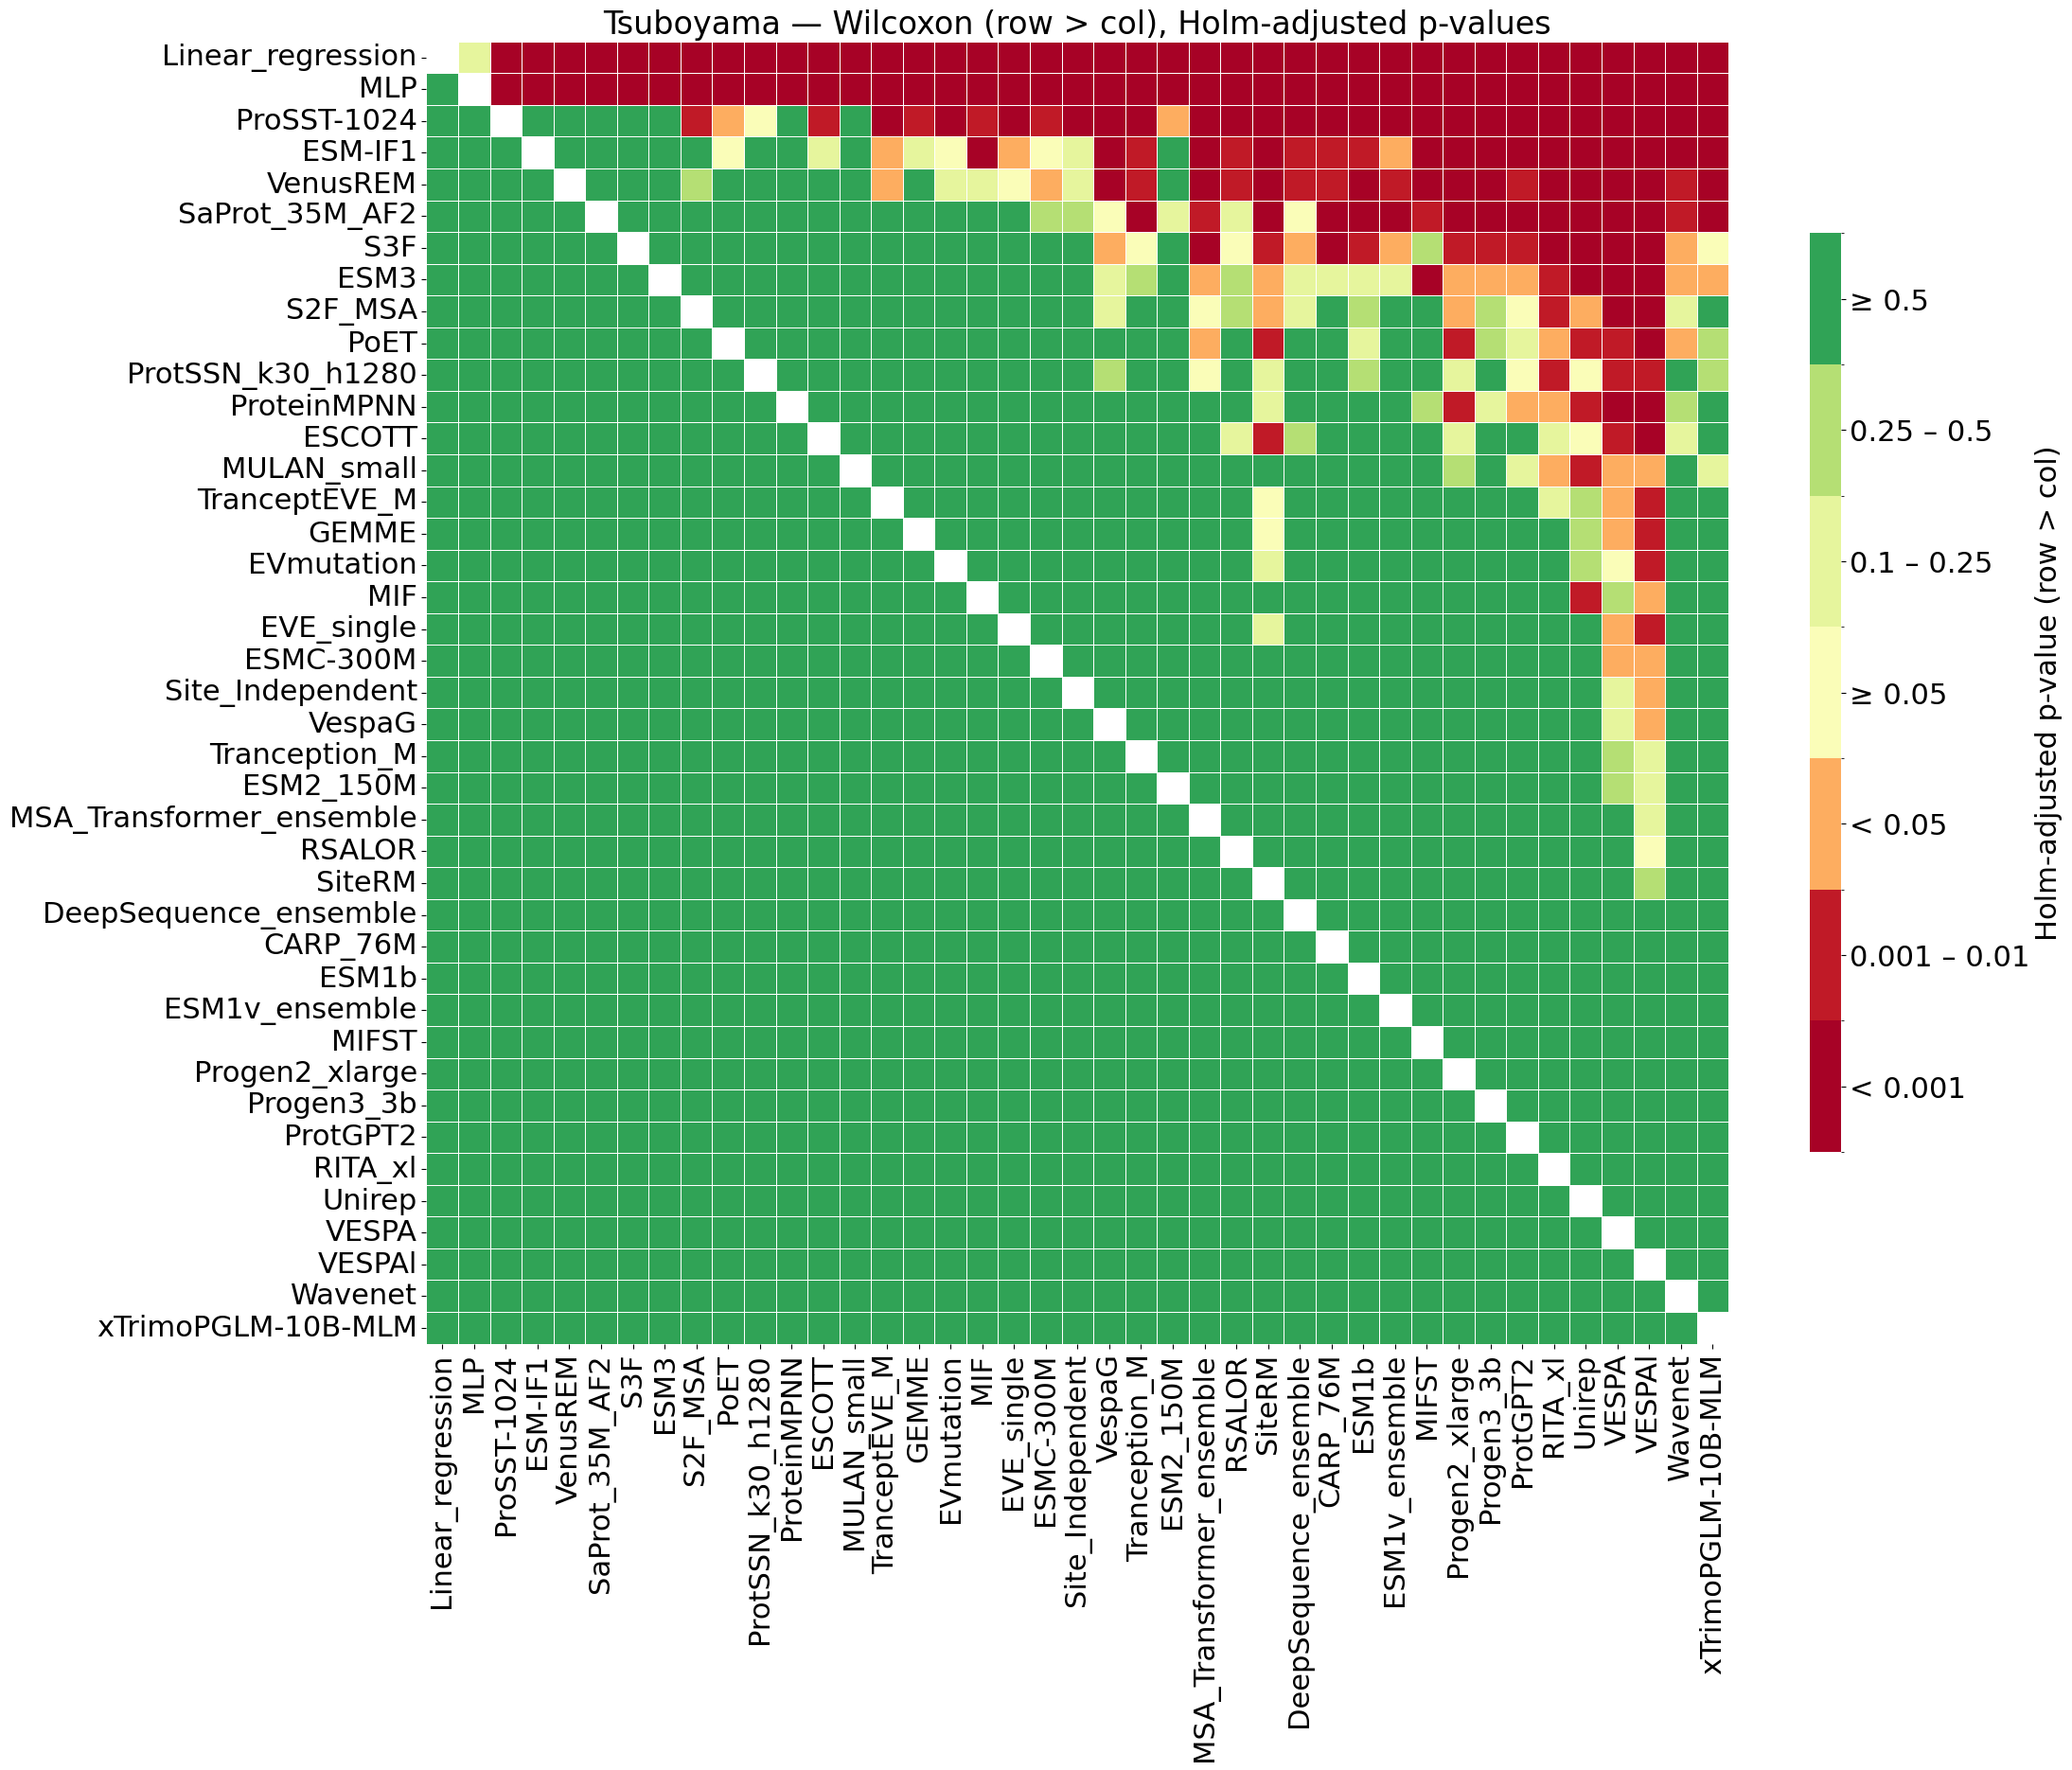

In [ ]:
from pathlib import Path
# if you put the functions into src/analysis_stats.py:

models_eval = Path("/wibicomfs/STBS/anastasia/epi_clean/results/tables/intermediate/models_evaluation")

# 1) Full gradient (Holm-adjusted p-values; diagonal white)
pmat_grad, pF = wilcoxon_heatmap_epistatic_best_full_gradient(
    models_eval_dir=models_eval,
    alpha=0.05,
    figsize=(22, 20),
    fontsize=22,
    out_png=models_eval / "tsuboyama_wilcoxon_full_gradient.png",
    out_csv=models_eval / "tsuboyama_wilcoxon_full_gradient.csv",
)
print("Saved full gradient heatmap. Friedman p =", pF)

# GFP heatmap

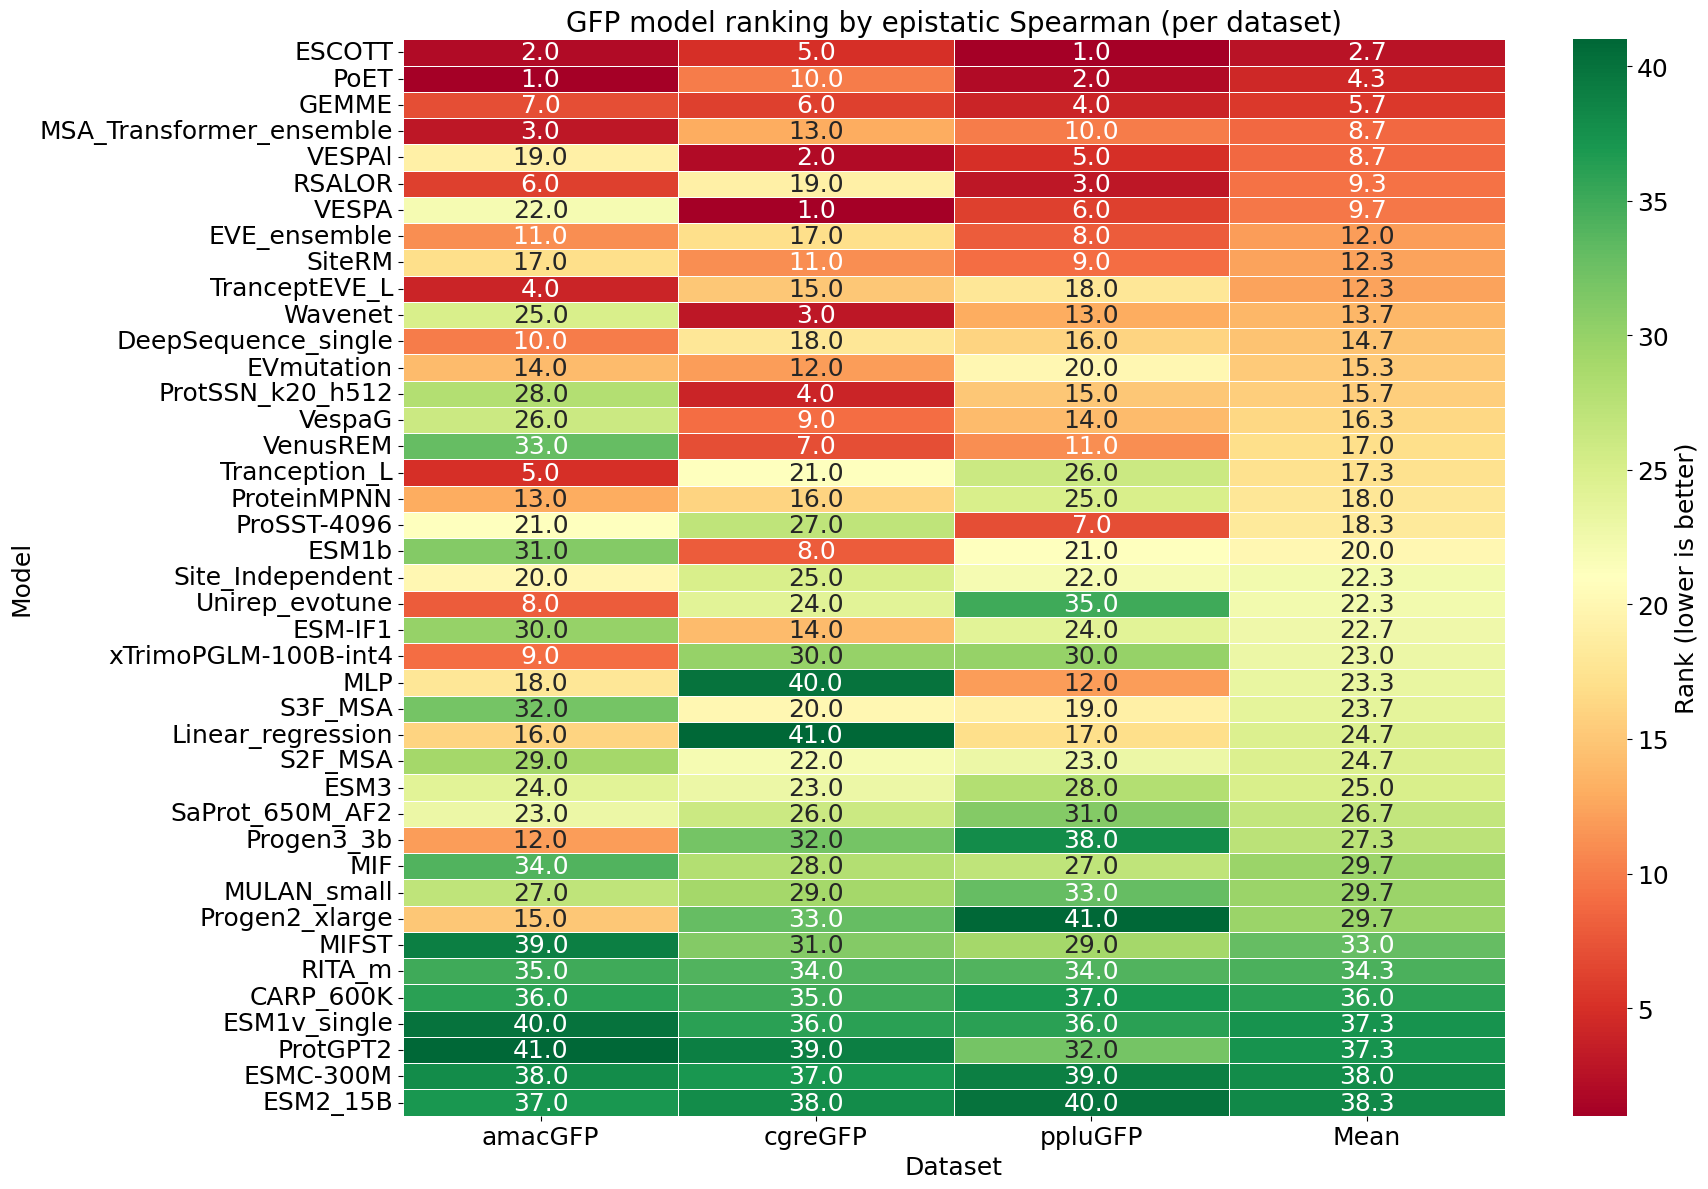

In [1]:
from pathlib import Path
from typing import Union, Optional, Tuple, List
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from src.utils import convert_name_to_gfp
from src.plotting import gfp_rank_heatmap

ranks, winners = gfp_rank_heatmap(
    models_eval_dir="/wibicomfs/STBS/anastasia/epi_clean/results/tables/intermediate/models_evaluation",
    source="best",               # or "all"
    subset="epistatic",          # or "all"
    out_pdf="heatmap.pdf",
    #dataset_order=["amacGFP", "cgreGFP", "ppluGFP"],   # optional
    annot=True
)

# Models dotplots

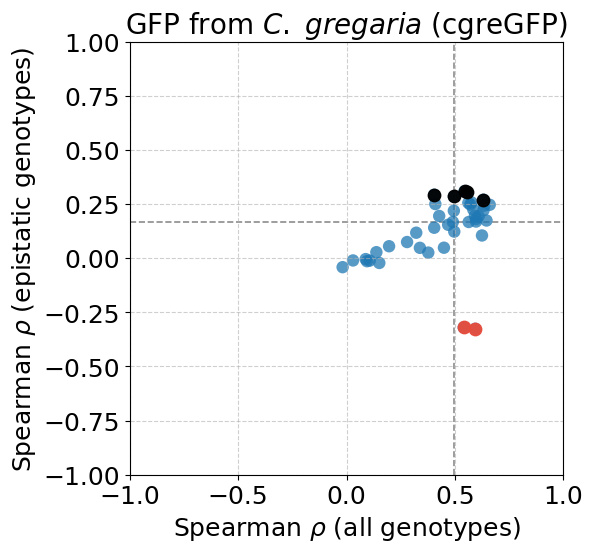

In [1]:
from src.plotting import models_dotplot_single
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,6))
models_dotplot_single(
    ax,
    csv_path="/wibicomfs/STBS/anastasia/epi_clean/results/tables/intermediate/models_evaluation/somermeyer_best_models.csv",
    dataset_key="D7PM05_CLYGR_Somermeyer_2022",  
)
plt.show()

In [ ]:
from src.plotting import models_dotplot_triplet
import matplotlib.pyplot as plt
from src.paths import supp_tables_dir

csv = "/wibicomfs/STBS/anastasia/epi_clean/results/tables/intermediate/models_evaluation/somermeyer_best_models.csv"
models_dotplot_triplet(
    csv_path=csv,
    out_table_csv=supp_tables_dir / "gfp_triplet_topk_and_baselines.csv",
    out_pdf="gfp.pdf"
)

(<Figure size 1800x600 with 3 Axes>,
 array([<Axes: title={'center': 'GFP from $\\mathit{C.\\ gregaria}$ (cgreGFP)'}, xlabel='Spearman $\\rho$ (all genotypes)', ylabel='Spearman $\\rho$ (epistatic genotypes)'>,
        <Axes: title={'center': 'GFP from $\\mathit{P.\\ plumata}$ (ppluGFP)'}, xlabel='Spearman $\\rho$ (all genotypes)', ylabel='Spearman $\\rho$ (epistatic genotypes)'>,
        <Axes: title={'center': 'GFP from $\\mathit{A.\\ macrodactyla}$ (amacGFP)'}, xlabel='Spearman $\\rho$ (all genotypes)', ylabel='Spearman $\\rho$ (epistatic genotypes)'>],
       dtype=object),
 ['D7PM05_CLYGR_Somermeyer_2022',
  'Q6WV12_9MAXI_Somermeyer_2022',
  'Q8WTC7_9CNID_Somermeyer_2022'])

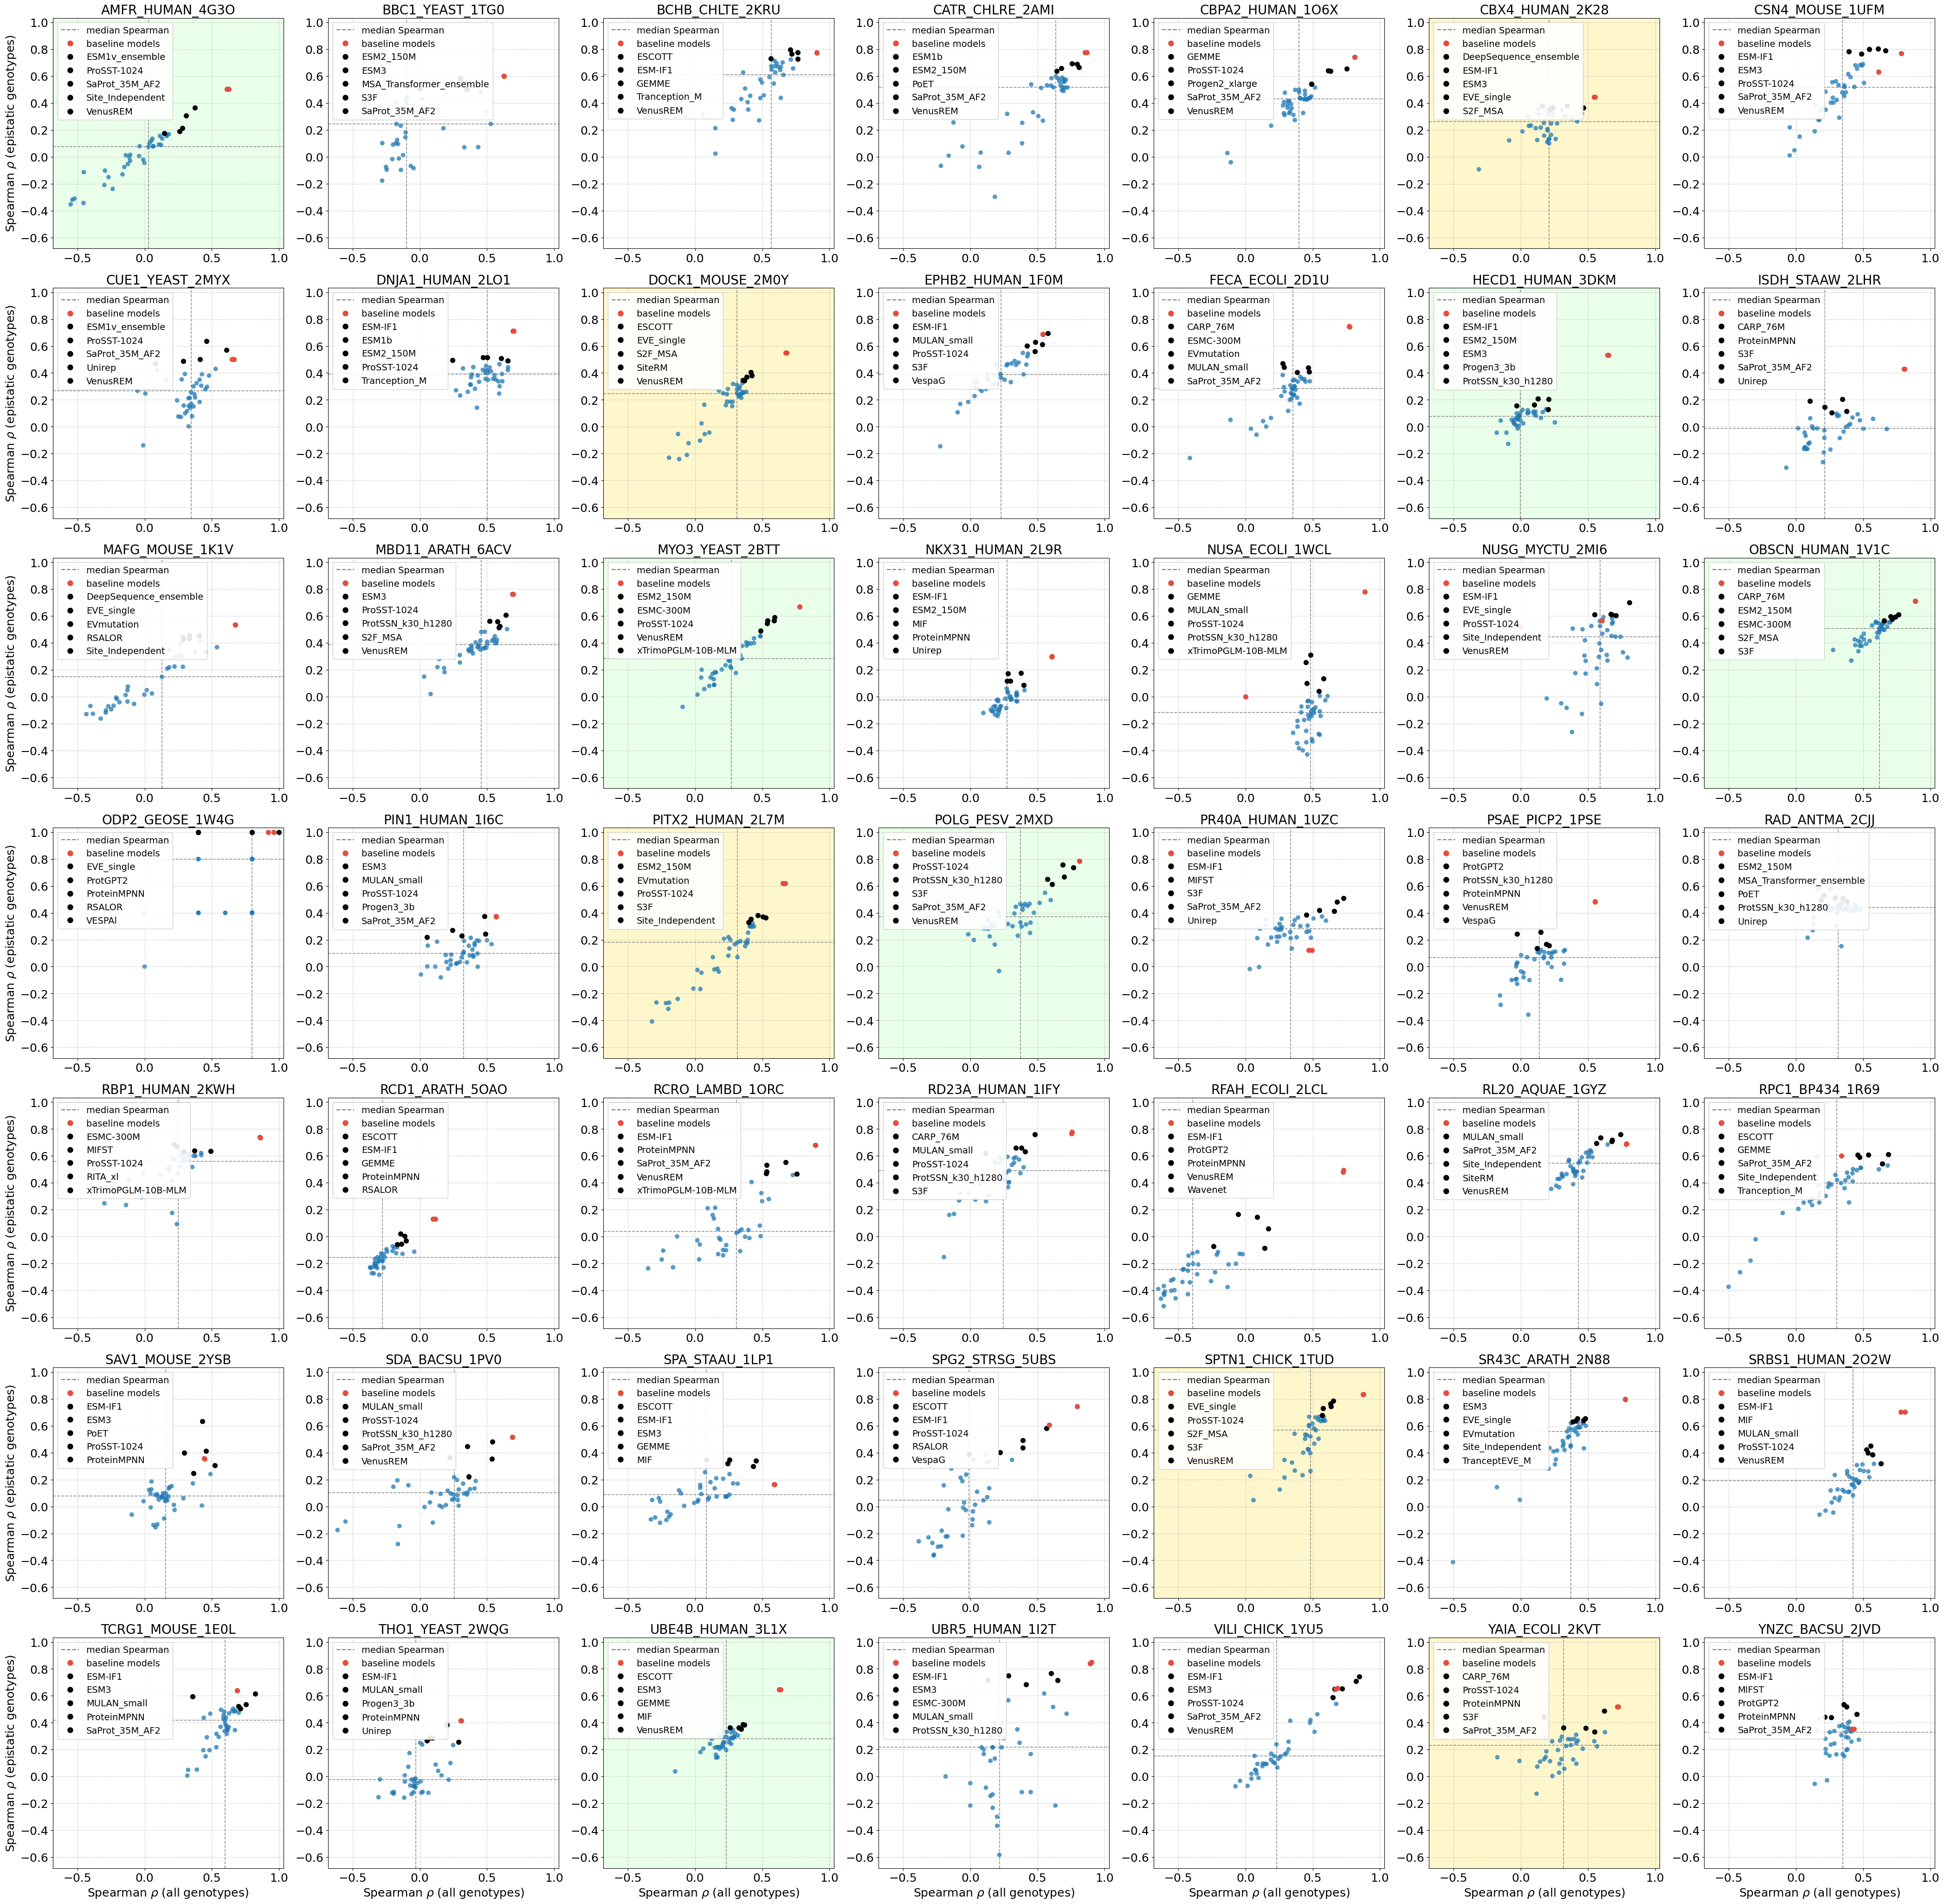

In [1]:
from src.plotting import models_dotplot_tsuboyama
import matplotlib.pyplot as plt
from src.paths import supp_tables_dir

fig, axes, used = models_dotplot_tsuboyama(
    csv_path="/wibicomfs/STBS/anastasia/epi_clean/results/tables/intermediate/models_evaluation/tsuboyama_best_models.csv",
    counts_csv="/wibicomfs/STBS/anastasia/epi_clean/results/tables/intermediate/counts.csv",
    out_png="tsuboyama_7x7.png",
    out_pdf="tsuboyama_7x7.pdf",
    out_table_csv=supp_tables_dir / "tsuboyama_topk_and_baselines.csv",
    point_size=50
)